# Demand Forecasting ML Project

## Importing the Libararies

In [1]:
# Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.formula.api as sm
from statsmodels.tsa import tsatools

## Loading Dataset And Preview

In [2]:
# Loading the final combined monthly dataset
df = pd.read_csv("final_project_combined_monthly.csv")

# Preview of the dataset
df.head()

,month_start,store_nbr,family,city,state,type,cluster,monthly_sales,monthly_onpromotion,monthly_transactions,...,holiday_days,national_event_count,regional_event_count,local_event_count,national_holiday_like_count,regional_holiday_like_count,local_holiday_like_count,month,year,quarter
0,01-01-2013,1,AUTOMOTIVE,Quito,Pichincha,D,13,68.0,0,47471,...,3,3,0,0,1,0,0,1,2013,1
1,01-01-2013,1,BABY CARE,Quito,Pichincha,D,13,0.0,0,47471,...,3,3,0,0,1,0,0,1,2013,1
2,01-01-2013,1,BEAUTY,Quito,Pichincha,D,13,45.0,0,47471,...,3,3,0,0,1,0,0,1,2013,1
3,01-01-2013,1,BEVERAGES,Quito,Pichincha,D,13,28777.0,0,47471,...,3,3,0,0,1,0,0,1,2013,1
4,01-01-2013,1,BOOKS,Quito,Pichincha,D,13,0.0,0,47471,...,3,3,0,0,1,0,0,1,2013,1


In [3]:
# Finding the dataset shape
print(df.shape)

# Checking the data types and structure
print(df.info())

# Checking the missing values
print(df.isnull().sum())

(99792, 22)
<class 'pandas.DataFrame'>
RangeIndex: 99792 entries, 0 to 99791
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   month_start                  99792 non-null  str    
 1   store_nbr                    99792 non-null  int64  
 2   family                       99792 non-null  str    
 3   city                         99792 non-null  str    
 4   state                        99792 non-null  str    
 5   type                         99792 non-null  str    
 6   cluster                      99792 non-null  int64  
 7   monthly_sales                99792 non-null  float64
 8   monthly_onpromotion          99792 non-null  int64  
 9   monthly_transactions         99792 non-null  int64  
 10  mean_daily_transactions      92433 non-null  float64
 11  avg_oil_price                99792 non-null  float64
 12  holiday_days                 99792 non-null  int64  
 13  national_event_

## Convert month_start to datetime and prepare the dataset for time-series analysis

In [4]:
# Convert month_start 
df['month_start'] = pd.to_datetime(df['month_start'], format='%d-%m-%Y')

# Sort by month_start
df = df.sort_values('month_start')

# Check the first 12 unique monthly dates BEFORE setting index
print(df['month_start'].drop_duplicates().sort_values().head(12))

# Set month_start as index
df = df.set_index('month_start')

# Check total number of unique months
print("Unique months:", df.index.nunique())

0       2013-01-01
2968    2013-02-01
4749    2013-03-01
6531    2013-04-01
8314    2013-05-01
10093   2013-06-01
11877   2013-07-01
13658   2013-08-01
15439   2013-09-01
17223   2013-10-01
19005   2013-11-01
20785   2013-12-01
Name: month_start, dtype: datetime64[us]
Unique months: 56


### Inspect the main parameters in the dataset

In [5]:
# Basic Dataset facts
print("Start month:", df.index.min())
print("End month:", df.index.max())
print("Number of stores:", df['store_nbr'].nunique())
print("Number of product families:", df['family'].nunique())
print("Number of cities:", df['city'].nunique())
print("Number of states:", df['state'].nunique())
print("Number of rows:", len(df))

Start month: 2013-01-01 00:00:00
End month: 2017-08-01 00:00:00
Number of stores: 54
Number of product families: 33
Number of cities: 22
Number of states: 16
Number of rows: 99792


In [6]:
# Main numerical parameters
df[['monthly_sales',
    'monthly_onpromotion',
    'monthly_transactions',
    'mean_daily_transactions',
    'avg_oil_price',
    'holiday_days',
    'national_event_count',
    'regional_event_count',
    'local_event_count']].describe()

,monthly_sales,monthly_onpromotion,monthly_transactions,mean_daily_transactions,avg_oil_price,holiday_days,national_event_count,regional_event_count,local_event_count
count,99792.000000,99792.000000,99792.000000,92433.000000,99792.000000,99792.000000,99792.000000,99792.000000,99792.000000
mean,10758.827884,78.269020,46785.365410,1694.627966,67.733710,2.681548,2.625000,0.010251,0.125331
std,31388.925081,261.753659,29679.488497,908.894479,25.522696,3.504848,3.720438,0.100729,0.443018
min,0.000000,0.000000,0.000000,466.633333,30.275238,0.000000,0.000000,0.000000,0.000000
25%,5.000000,0.000000,28995.250000,1088.900000,46.485195,0.000000,0.000000,0.000000,0.000000
50%,370.000000,0.000000,40559.500000,1402.193548,53.009795,2.000000,1.500000,0.000000,0.000000
75%,6147.000000,28.000000,57561.750000,2075.333333,94.892533,4.000000,3.250000,0.000000,0.000000
max,473316.000000,20762.000000,167005.000000,5566.833333,106.572727,18.000000,21.000000,1.000000,3.000000


### Handling the Null Values

In [7]:
# Fill missing values in mean_daily_transactions with 0
df['mean_daily_transactions'] = df['mean_daily_transactions'].fillna(0)

# Confirm cleaning after removing null values
print(df.isnull().sum())

store_nbr                      0
family                         0
city                           0
state                          0
type                           0
cluster                        0
monthly_sales                  0
monthly_onpromotion            0
monthly_transactions           0
mean_daily_transactions        0
avg_oil_price                  0
holiday_days                   0
national_event_count           0
regional_event_count           0
local_event_count              0
national_holiday_like_count    0
regional_holiday_like_count    0
local_holiday_like_count       0
month                          0
year                           0
quarter                        0
dtype: int64


The combined monthly dataset contained missing values only in the mean_daily_transactions field. The missing values were imputed with 0 to preserve complete monthly sales records for time-series modeling, since this variable was used as a supporting contextual feature rather than the forecasting target.

 ## Creating the Yearly total sales 

year
2013    140.419014
2014    209.474246
2015    240.880101
2016    288.654523
2017    194.217068
Name: monthly_sales, dtype: float64


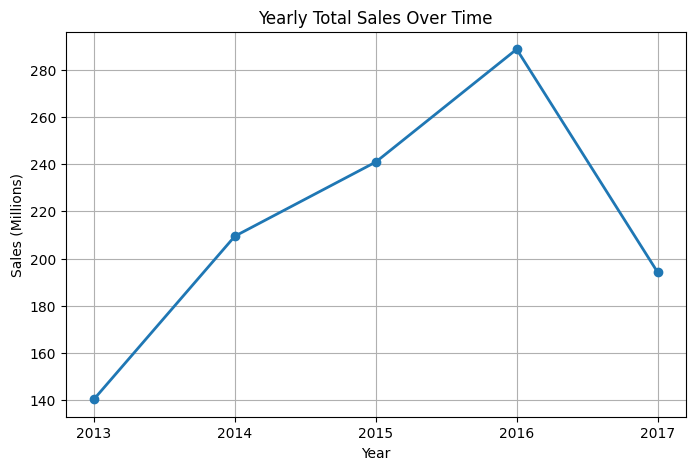

In [8]:
# Yearly total sales for business overview
yearly_sales = df.groupby('year')['monthly_sales'].sum() / 1000000

print(yearly_sales)

#plotting the sales over year line chart
plt.figure(figsize=(8,5))
yearly_sales.plot(marker='o', linewidth=2, grid=True)
plt.title("Yearly Total Sales Over Time")
plt.xlabel("Year")
plt.ylabel("Sales (Millions)")
plt.xticks(yearly_sales.index)   # show only integer years
plt.show()

month_start
2013-01-01    10.327625
2013-02-01     9.658960
2013-03-01    11.428497
2013-04-01    10.993465
2013-05-01    11.597704
2013-06-01    11.689344
2013-07-01    11.257401
2013-08-01    11.737789
2013-09-01    11.792933
2013-10-01    11.775620
2013-11-01    12.356559
2013-12-01    15.803117
Name: monthly_sales, dtype: float64


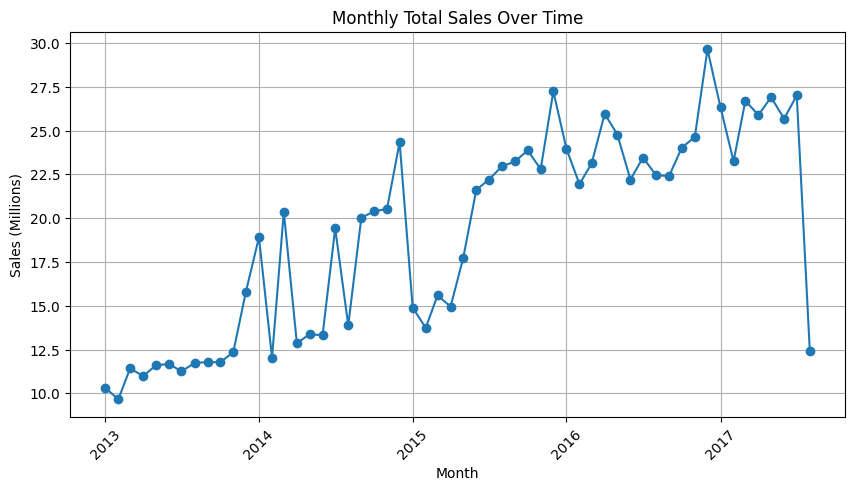

In [9]:
# Monthly total sales for business overview
monthly_total_sales = df.groupby(level=0)['monthly_sales'].sum() / 1000000

print(monthly_total_sales.head(12))

#plotting the monthly total sales
plt.figure(figsize=(10,5))
plt.plot(monthly_total_sales.index, monthly_total_sales.values, marker='o')
plt.title("Monthly Total Sales Over Time")
plt.xlabel("Month")
plt.ylabel("Sales (Millions)")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

## Cleaning the incomplete final month after monthly total sales

After plotting the monthly total sales trend, the last observation appears unusually low.
This is not treated as a true demand outlier. Instead, it is considered an incomplete final month,
which would distort later family selection, store selection, and forecasting.

To keep the monthly series consistent, the final incomplete month is removed before the next steps.

In [10]:
# Check the last few monthly total sales values
print(monthly_total_sales.tail())

month_start
2017-04-01    25.895308
2017-05-01    26.911847
2017-06-01    25.682822
2017-07-01    27.011478
2017-08-01    12.433323
Name: monthly_sales, dtype: float64


In [11]:
# Identify the last month in the dataset
last_month = monthly_total_sales.index.max()
print("Month to remove:", last_month)

Month to remove: 2017-08-01 00:00:00


In [12]:
# Remove the last incomplete month from the main dataset
df = df[df.index != last_month]

# Rebuild monthly total sales after removal
monthly_total_sales = df.groupby(level=0)['monthly_sales'].sum() / 1000000

# Check the cleaned last few values
print(monthly_total_sales.tail())

month_start
2017-03-01    26.704018
2017-04-01    25.895308
2017-05-01    26.911847
2017-06-01    25.682822
2017-07-01    27.011478
Name: monthly_sales, dtype: float64


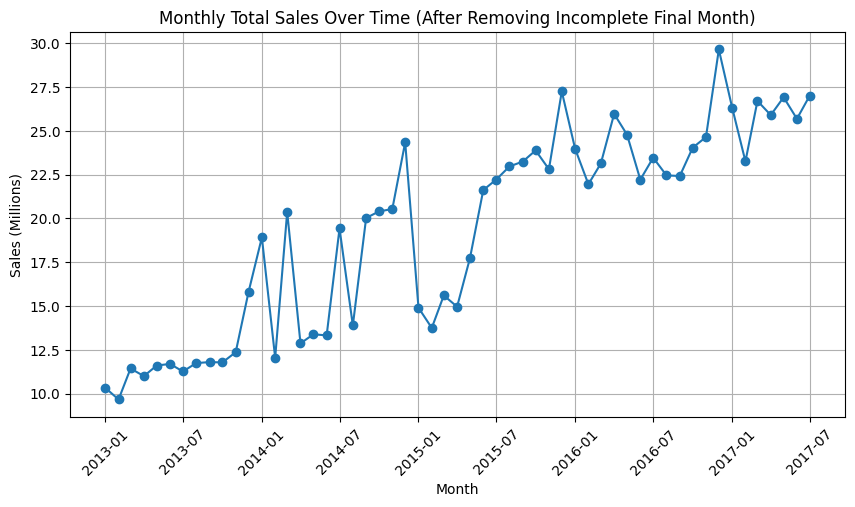

In [13]:
# Plot monthly total sales again after cleaning
plt.figure(figsize=(10,5))
plt.plot(monthly_total_sales.index, monthly_total_sales.values, marker='o')
plt.title("Monthly Total Sales Over Time (After Removing Incomplete Final Month)")
plt.xlabel("Month")
plt.ylabel("Sales (Millions)")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

## Find the top product families

At this stage, the goal is to identify which product families contribute the most to
overall retail sales. Since the dataset is organized at the month-store-family level,
choosing a high-impact family is an important step before selecting the final forecasting series.

Families with higher total sales are more relevant for business decision-making because
they have a stronger effect on inventory planning, replenishment, and retail operations.
For this reason, the analysis focuses first on comparing total sales across product families.

In [14]:
# Total sales by family
family_sales = df.groupby('family')['monthly_sales'].sum().sort_values(ascending=False)

# Convert to millions
family_sales_millions = family_sales / 1000000

# Show top 10 families
print(family_sales_millions.head(10))

family
GROCERY I        339.752538
BEVERAGES        214.144583
PRODUCE          120.849090
CLEANING          96.545431
DAIRY             63.813168
BREAD/BAKERY      41.697532
POULTRY           31.572152
MEATS             30.783500
PERSONAL CARE     24.333084
DELI              23.865098
Name: monthly_sales, dtype: float64


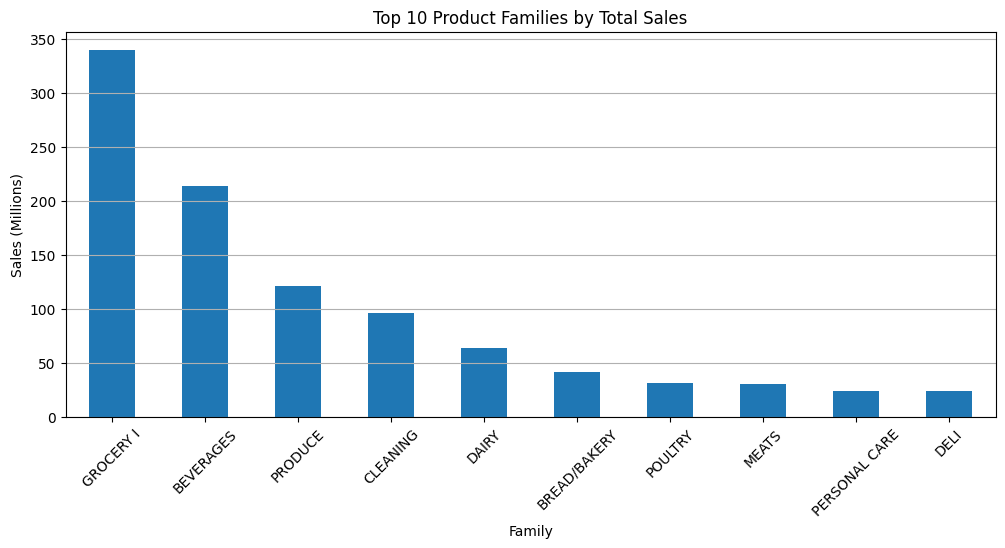

In [15]:
# Plot top 10 product families
plt.figure(figsize=(12,5))
family_sales_millions.head(10).plot(kind='bar')
plt.title("Top 10 Product Families by Total Sales")
plt.xlabel("Family")
plt.ylabel("Sales (Millions)")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

### Insight 
The output shows that **GROCERY I** is the highest-sales product family, followed by
**BEVERAGES** and **PRODUCE**. This suggests that GROCERY I is the most business-relevant
candidate for the forecasting analysis because it contributes the largest share of total sales.

Selecting a major family such as GROCERY I makes the forecasting exercise more useful from
a business perspective, since improvements in forecast accuracy for this family can have a
greater effect on retail planning and stock management.

## Compare store-level sales within the selected family

After identifying the most important product family, the next step is to compare store-level
sales within that family. This helps narrow the forecasting problem from a broad family-level
view to a more specific and realistic **store-family forecasting unit**.

The purpose of this step is to find stores that make the largest contribution to sales within
the selected family and to identify strong candidate series for time-series forecasting.
A store with high sales and a complete monthly history is usually a better candidate for
forecasting because it is more relevant to business planning and may provide a clearer demand pattern.

In [16]:
# Select the highest-sales family
selected_family = family_sales.idxmax()
print("Selected family:", selected_family)

# Filter data for the selected family
family_df = df[df['family'] == selected_family]

# Total sales by store for the selected family
store_sales_family = family_df.groupby('store_nbr')['monthly_sales'].sum().sort_values(ascending=False)

# Convert to millions
store_sales_family_millions = store_sales_family / 1000000

# Show top 10 stores
print(store_sales_family_millions.head(10))

Selected family: GROCERY I
store_nbr
44    16.243003
45    16.185070
47    15.362355
46    14.201831
3     12.855278
48    12.703174
49    10.972850
11    10.925688
9     10.245913
50    10.020661
Name: monthly_sales, dtype: float64


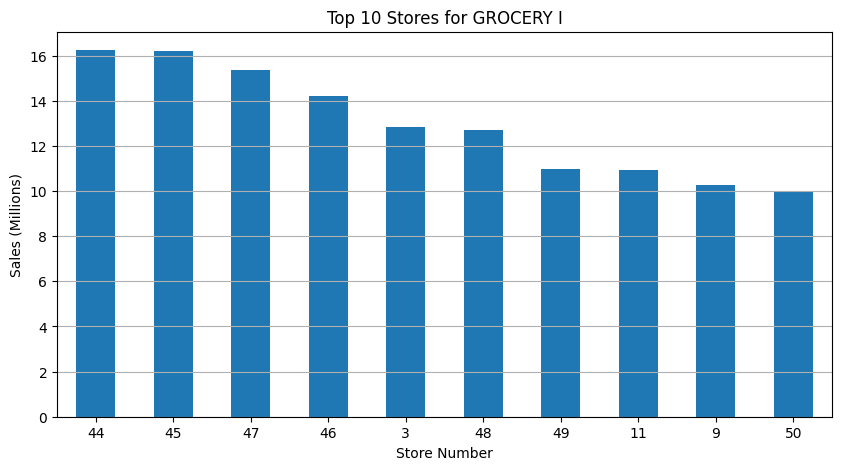

In [17]:
#Plot top 10 stores for the selected family
plt.figure(figsize=(10,5))
store_sales_family_millions.head(10).plot(kind='bar')
plt.title(f"Top 10 Stores for {selected_family}")
plt.xlabel("Store Number")
plt.ylabel("Sales (Millions)")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

### Insight

Within **GROCERY I**, the top-performing stores are **44, 45, 47, 46, and 3**.
These stores should be treated as the main candidates for the final forecasting series.

However, the final store should not be selected only on total sales. The next step is to compare
the monthly sales patterns of these top stores over time, so that the final forecasting series
can be chosen based on both business importance and time-series sui

## Compare the top candidate stores over time

In [18]:
# Select top 5 stores from the chosen family
top_5_stores = store_sales_family.head(5).index
print("Top 5 candidate stores:", list(top_5_stores))

# Filter the selected family for only these stores
candidate_df = family_df[family_df['store_nbr'].isin(top_5_stores)]

# Build monthly sales series for the candidate stores
candidate_series = candidate_df.groupby([candidate_df.index, 'store_nbr'])['monthly_sales'].sum().unstack()

# Check number of monthly observations for each candidate store
print(candidate_series.notna().sum())


Top 5 candidate stores: [44, 45, 47, 46, 3]
store_nbr
3     55
44    55
45    55
46    55
47    55
dtype: int64


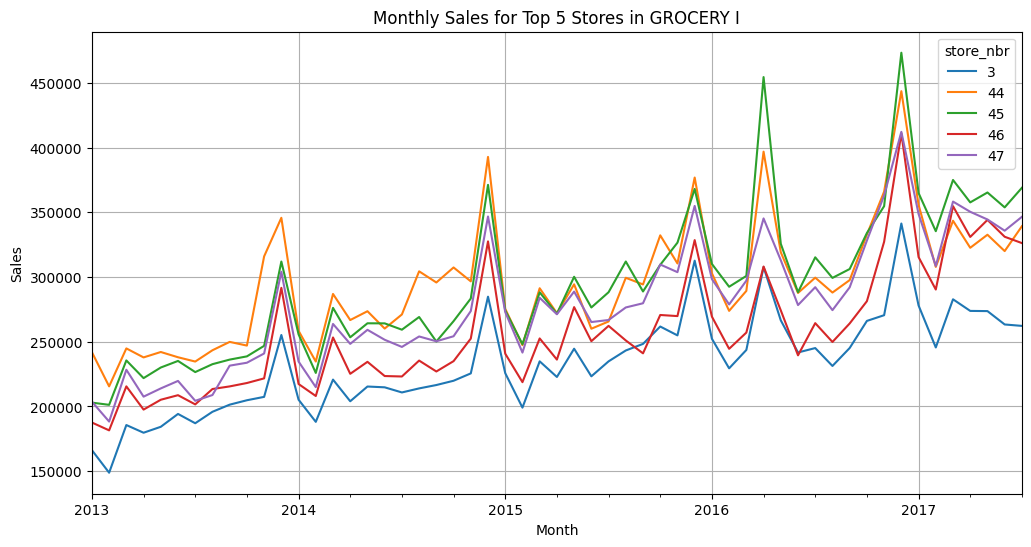

In [19]:
# Plot monthly sales for the top 5 candidate stores
plt.figure(figsize=(12,6))
candidate_series.plot(ax=plt.gca())
plt.title(f"Monthly Sales for Top 5 Stores in {selected_family}")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

### Interpretation

The comparison of the top candidate stores shows that all selected stores have strong sales
within the GROCERY I family, but their monthly demand patterns are not equally suitable
for forecasting.

Although Store 45 has slightly higher peaks in some periods, Store 44 shows a strong sales level
with a comparatively smoother and more stable pattern over time. This makes Store 44 a better
choice for the final forecasting analysis because it combines high business relevance with a
series that is more suitable for time-series modeling.

Due to these reasons, the final forecasting series selected for the project is: **GROCERY I – Store 44**

### Compare total sales by state

The dataset also includes geographic variables such as state and city. These variables help
show whether retail demand is concentrated in certain regions.

In [20]:
# Total sales by state
state_sales = df.groupby('state')['monthly_sales'].sum().sort_values(ascending=False)

# Convert to millions
state_sales_millions = state_sales / 1000000

# Show output
print(state_sales_millions)

state
Pichincha                         578.864897
Guayas                            163.197032
Azuay                              48.577418
Tungurahua                         39.886165
Santo Domingo de los Tsachilas     35.371475
El Oro                             32.928282
Los Rios                           31.548662
Manabi                             24.294905
Cotopaxi                           20.964507
Loja                               18.675425
Esmeraldas                         16.144473
Bolivar                            12.909472
Imbabura                           11.335329
Santa Elena                        11.273528
Chimborazo                         11.261692
Pastaza                             3.978368
Name: monthly_sales, dtype: float64


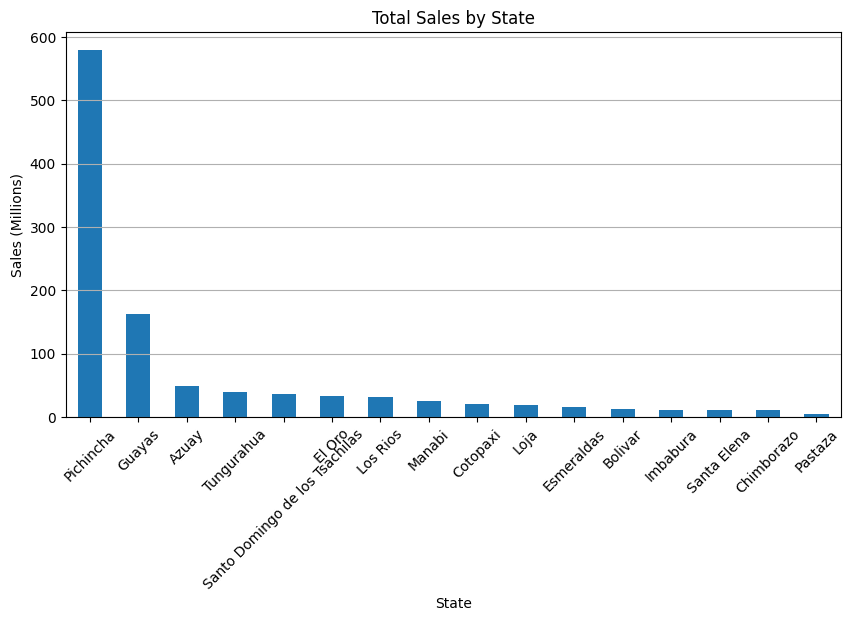

In [21]:
# Plot sales by state
plt.figure(figsize=(10,5))
state_sales_millions.plot(kind='bar')
plt.title("Total Sales by State")
plt.xlabel("State")
plt.ylabel("Sales (Millions)")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

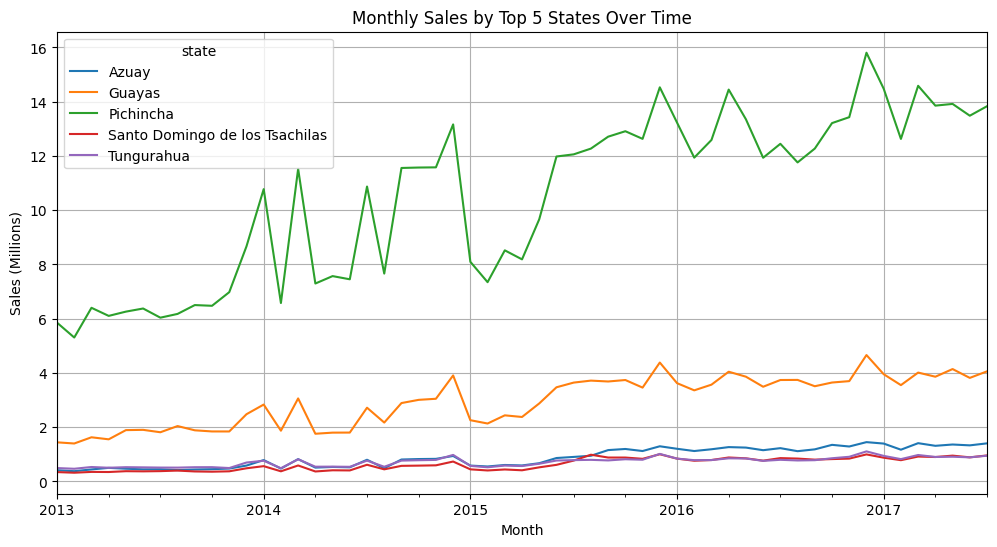

In [22]:
# Select top 5 states
top_5_states = state_sales.head(5).index

# Monthly sales by top 5 states
state_time_top = df[df['state'].isin(top_5_states)]
state_time_top = state_time_top.groupby([state_time_top.index, 'state'])['monthly_sales'].sum().unstack()

# Convert to millions
state_time_top_millions = state_time_top / 1000000

# Plotting the monthly sales for top 5 states
plt.figure(figsize=(12,6))
state_time_top_millions.plot(ax=plt.gca())
plt.title("Monthly Sales by Top 5 States Over Time")
plt.xlabel("Month")
plt.ylabel("Sales (Millions)")
plt.grid(True)
plt.show()

In [23]:
# Total sales by city
city_sales = df.groupby('city')['monthly_sales'].sum().sort_values(ascending=False)

# Convert to millions
city_sales_millions = city_sales / 1000000

# Show top 10 cities
print(city_sales_millions.head(10))

city
Quito            550.859688
Guayaquil        121.514718
Cuenca            48.577418
Ambato            39.886165
Santo Domingo     35.371475
Machala           32.928282
Cayambe           28.005209
Latacunga         20.964507
Daule             18.968203
Loja              18.675425
Name: monthly_sales, dtype: float64


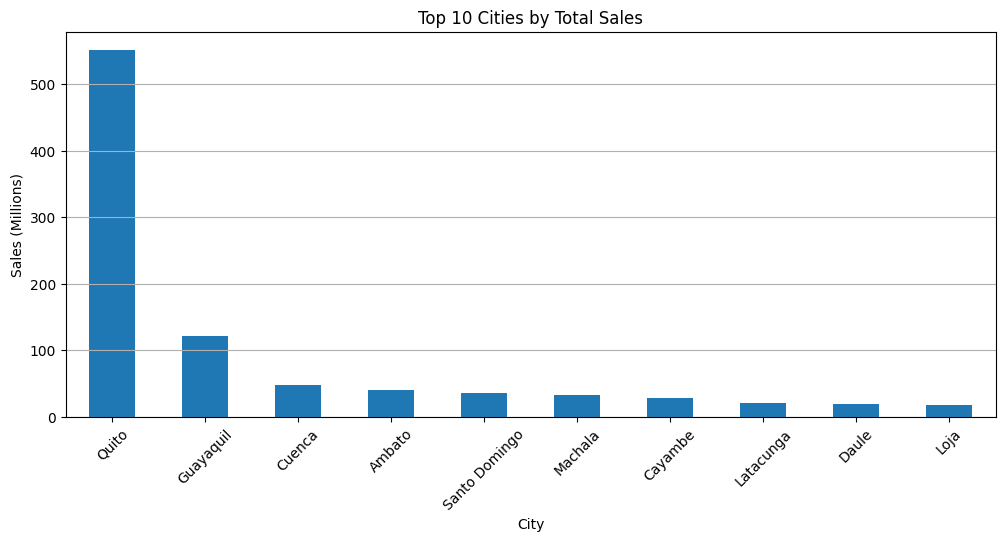

In [24]:
# Plot top 10 cities by total sales
plt.figure(figsize=(12,5))
city_sales_millions.head(10).plot(kind='bar')
plt.title("Top 10 Cities by Total Sales")
plt.xlabel("City")
plt.ylabel("Sales (Millions)")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

In [25]:
# Top state
top_state = df.groupby('state')['monthly_sales'].sum().sort_values(ascending=False).idxmax()

# Top city
top_city = df.groupby('city')['monthly_sales'].sum().sort_values(ascending=False).idxmax()

# Top store
top_store = df.groupby('store_nbr')['monthly_sales'].sum().sort_values(ascending=False).idxmax()

# Top family
top_family = df.groupby('family')['monthly_sales'].sum().sort_values(ascending=False).idxmax()

# Printing the top 
print("Top state:", top_state)
print("Top city:", top_city)
print("Top store:", top_store)
print("Top family:", top_family)

Top state: Pichincha
Top city: Quito
Top store: 44
Top family: GROCERY I


# Create the final forecasting series

In [26]:
# Final selected combination
selected_family = 'GROCERY I'
selected_store = 44

print("Selected family:", selected_family)
print("Selected store:", selected_store)

# Create final forecasting series
series_final = df[(df['family'] == selected_family) & (df['store_nbr'] == selected_store)]
series_final = series_final.groupby(level=0)['monthly_sales'].sum().sort_index()

# Checking  first month values
print(series_final.head())
print("Number of monthly observations:", len(series_final))

Selected family: GROCERY I
Selected store: 44
month_start
2013-01-01    241910.0
2013-02-01    215495.0
2013-03-01    244823.0
2013-04-01    237864.0
2013-05-01    242045.0
Name: monthly_sales, dtype: float64
Number of monthly observations: 55


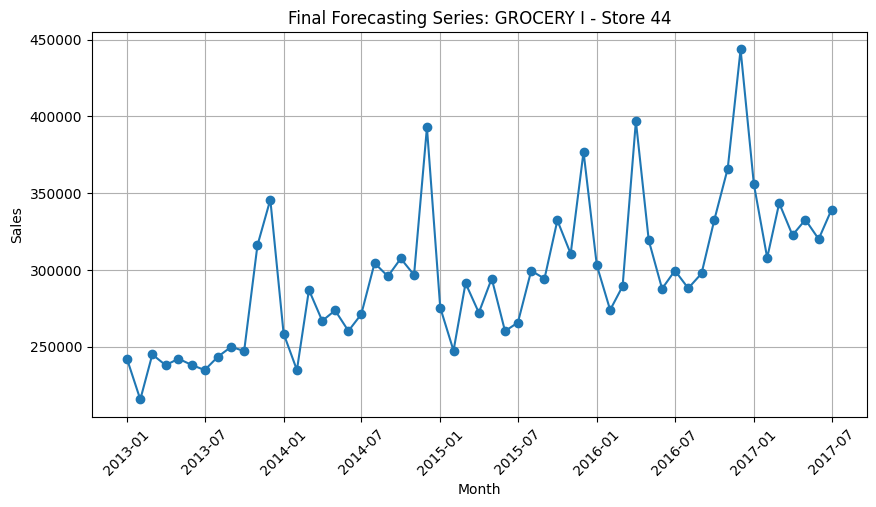

In [27]:
# Plot final forecasting series
plt.figure(figsize=(10,5))
plt.plot(series_final.index, series_final.values, marker='o')
plt.title(f"Final Forecasting Series: {selected_family} - Store {selected_store}")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

### Insight

The final forecasting series represents monthly sales for GROCERY I in Store 44.
This series will be used in the next steps to study trend and seasonality, partition the data
into training and validation sets, and compare forecasting models.

## Identify trend and seasonality in the final forecasting series

Before evaluating forecasting models, the final monthly series should be examined for its
main time-series components, especially trend and seasonality.

A centered moving average is used to suppress short-term noise and highlight the underlying
trend, while monthly average sales are used to inspect whether the series has a recurring
seasonal pattern across months.

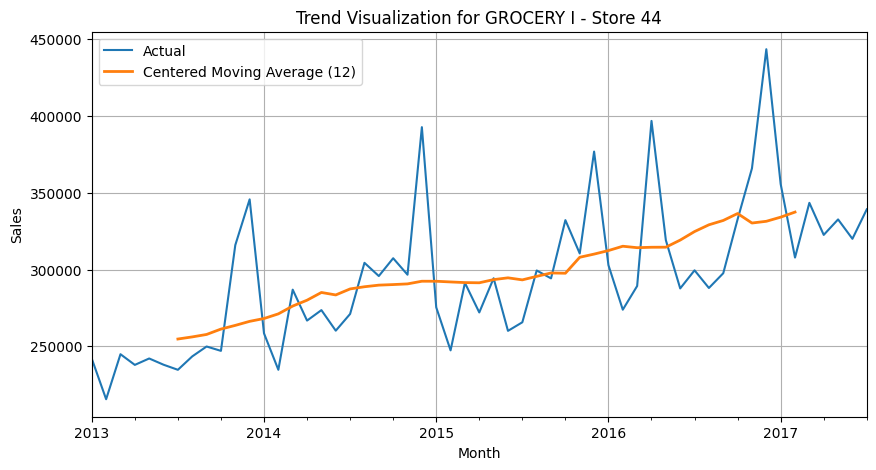

In [28]:
#Centered moving average for trend visualization
ma_centered = series_final.rolling(12, center=True).mean()

#Plotting the trend 
plt.figure(figsize=(10,5))
series_final.plot(label='Actual', linewidth=1.5)
ma_centered.plot(label='Centered Moving Average (12)', linewidth=2)
plt.title(f"Trend Visualization for {selected_family} - Store {selected_store}")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
# Creating the dataframe for seasonality analysis
series_df = series_final.to_frame(name='Sales')
series_df['Month'] = series_df.index.month
series_df['Year'] = series_df.index.year

# Average sales by month across years
monthly_pattern = series_df.groupby('Month')['Sales'].mean()

print(monthly_pattern)

Month
1     286860.6000
2     255830.6000
3     291154.6000
4     299217.2000
5     292347.4000
6     273179.4000
7     282018.6000
8     283791.5000
9     284367.0000
10    304836.0000
11    322248.2500
12    389747.5095
Name: Sales, dtype: float64


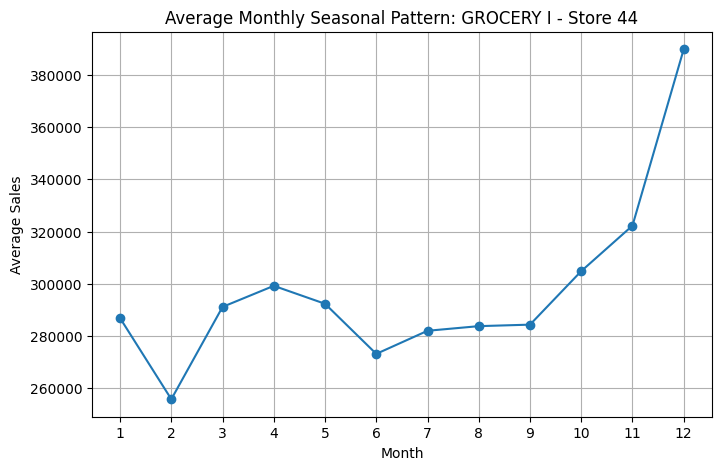

In [30]:
#Plotting the Seasonal Pattern
plt.figure(figsize=(8,5))
monthly_pattern.plot(marker='o')
plt.title(f"Average Monthly Seasonal Pattern: {selected_family} - Store {selected_store}")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.grid(True)
plt.xticks(range(1,13))
plt.show()

Year       2013      2014        2015      2016      2017
Month                                                    
1      241910.0  258424.0  275399.000  302850.0  355720.0
2      215495.0  234679.0  247334.000  273836.0  307809.0
3      244823.0  286898.0  291310.000  289269.0  343473.0
4      237864.0  266740.0  272043.000  396859.0  322580.0
5      242045.0  273557.0  294322.000  319147.0  332666.0
6      237982.0  260157.0  260040.000  287695.0  320023.0
7      234664.0  271062.0  265636.000  299499.0  339232.0
8      243398.0  304385.0  299401.000  287982.0       NaN
9      249854.0  295769.0  294239.000  297606.0       NaN
10     247008.0  307372.0  332201.000  332763.0       NaN
11     315937.0  296636.0  310468.000  365952.0       NaN
12     345746.0  392794.0  376872.038  443578.0       NaN


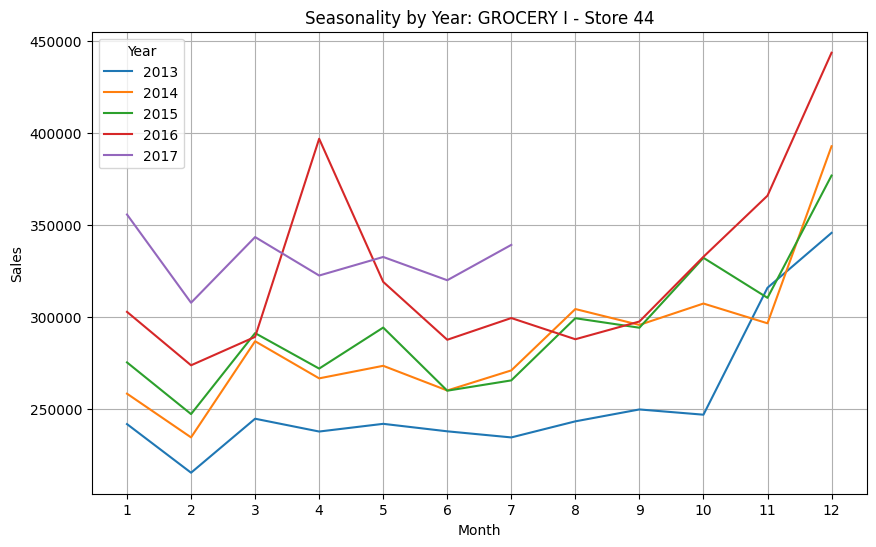

In [31]:
# Year by month view to inspect repeated monthly pattern
seasonal_view = series_df.pivot(index='Month', columns='Year', values='Sales')
print(seasonal_view)

# Plotting the seasonal plot by each year
plt.figure(figsize=(10,6))
seasonal_view.plot(ax=plt.gca())
plt.title(f"Seasonality by Year: {selected_family} - Store {selected_store}")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.xticks(range(1,13))
plt.show()

### Trend and Seasonality Interpretation

The centered moving average shows that the final forecasting series has an overall upward trend over time. This indicates that sales for GROCERY I in Store 44 generally increased during the study period.

The average monthly seasonal pattern suggests that sales are not uniform across months. Later months tend to show higher average sales than earlier months, which indicates the presence of seasonality. The year-wise seasonal plot also shows that monthly sales patterns differ across years, while still maintaining a broadly similar shape.

Overall, the final series contains both trend and seasonality, so model evaluation should include not only smoothing methods but also a regression-based forecasting model that can account for these patterns.

## Fitting the regression model with trend and month seasonality

The first regression-based forecasting model uses:
- **trend** to capture the overall direction of the series
- **Month** as a categorical variable to capture seasonality
  

In [32]:
# Convert final series into regression ready dataframe
series_reg_df = tsatools.add_trend(series_final, trend='ct')
series_reg_df['Month'] = series_reg_df.index.month

# Preview
print(series_reg_df.head())
print(series_reg_df.tail())

             monthly_sales  const  trend  Month
month_start                                    
2013-01-01        241910.0    1.0    1.0      1
2013-02-01        215495.0    1.0    2.0      2
2013-03-01        244823.0    1.0    3.0      3
2013-04-01        237864.0    1.0    4.0      4
2013-05-01        242045.0    1.0    5.0      5
             monthly_sales  const  trend  Month
month_start                                    
2017-03-01        343473.0    1.0   51.0      3
2017-04-01        322580.0    1.0   52.0      4
2017-05-01        332666.0    1.0   53.0      5
2017-06-01        320023.0    1.0   54.0      6
2017-07-01        339232.0    1.0   55.0      7


## Partition the regression-ready time-series data

To compare forecasting models properly, the regression-ready dataset is divided into:
- a training set containing the earlier observations
- a validation set containing the later observations

In [33]:
# Partition the regression-ready dataframe
nValid = 12
nTrain = len(series_reg_df) - nValid

train_df = series_reg_df[:nTrain]
valid_df = series_reg_df[nTrain:]

print("Training observations:", len(train_df))
print("Validation observations:", len(valid_df))


Training observations: 43
Validation observations: 12


In [34]:
# Create training and validation series
train_ts = train_df['monthly_sales']
valid_ts = valid_df['monthly_sales']

## Seasonal Naive Forecast

Final series shows monthly seasonality, a seasonal naive forecast is used as the benchmark.
Each month in the validation period is forecast using the same month from the previous year.

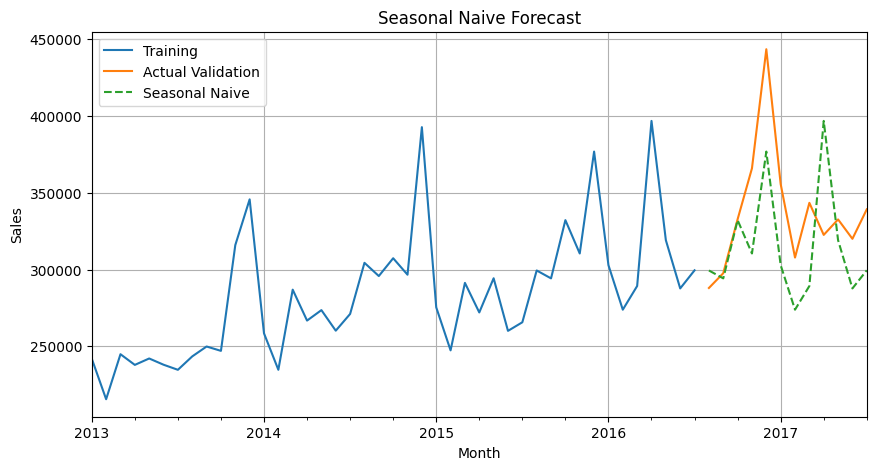

In [35]:
# Seasonal naive forecast
seasonal_naive_pred = pd.Series(train_ts[-12:].values, index=valid_ts.index)

# Plot
plt.figure(figsize=(10,5))
train_ts.plot(label='Training')
valid_ts.plot(label='Actual Validation')
seasonal_naive_pred.plot(label='Seasonal Naive', linestyle='--')
plt.title("Seasonal Naive Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

##  Trailing Moving Average Forecast

A 12-month trailing moving average is used to create a simple forecasting model.
The forecast for the validation period is based on the last moving average value from the training period.

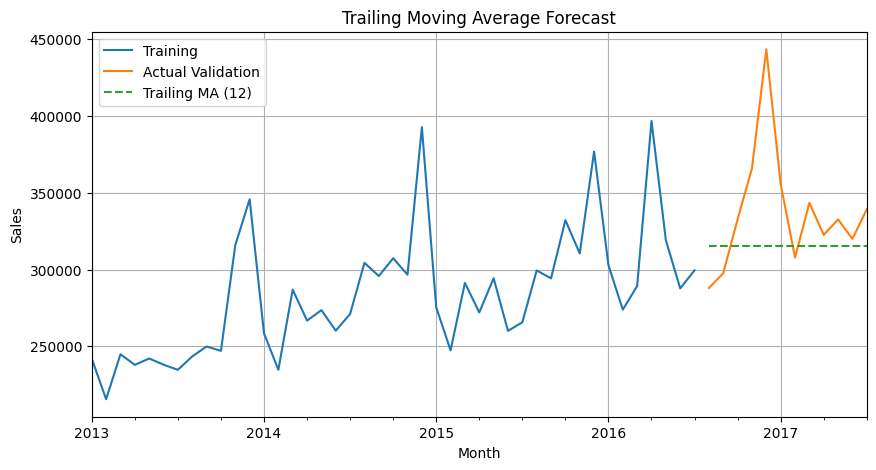

In [36]:
# Moving average on training set
ma_trailing = train_ts.rolling(12).mean()
last_ma = ma_trailing.iloc[-1]

# Forecast for validation period
ma_trailing_pred = pd.Series(last_ma, index=valid_ts.index)

# Plotting  the Trailing Moving average
plt.figure(figsize=(10,5))
train_ts.plot(label='Training')
valid_ts.plot(label='Actual Validation')
ma_trailing_pred.plot(label='Trailing MA (12)', linestyle='--')
plt.title("Trailing Moving Average Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

##  Regression Forecast with Trend and Month Seasonality

This model uses the time trend and month as a categorical variable to capture 

In [37]:
# Regression model with trend and month seasonality
reg_model_1 = sm.ols(formula='monthly_sales ~ trend + C(Month)', data=train_df).fit()

# Forecast validation period
reg_pred_1 = reg_model_1.predict(valid_df)

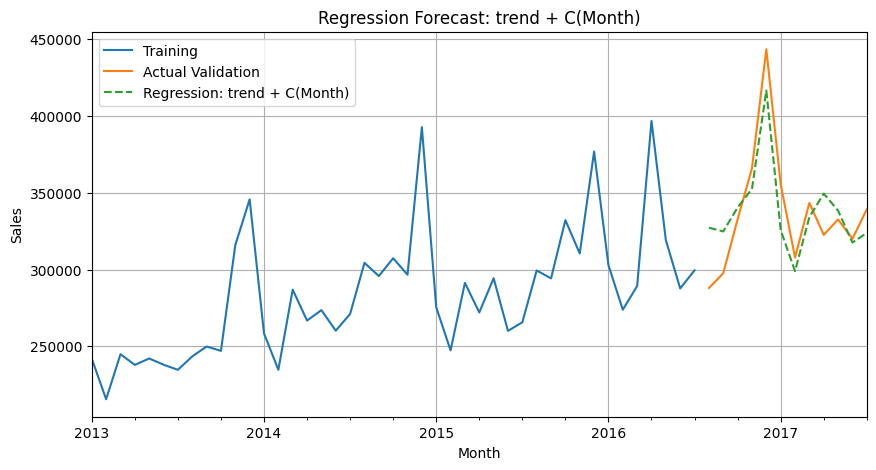

In [38]:
# Plotting the Regression: trend + C(Month)
plt.figure(figsize=(10,5))
train_ts.plot(label='Training')
valid_ts.plot(label='Actual Validation')
reg_pred_1.plot(label='Regression: trend + C(Month)', linestyle='--')
plt.title("Regression Forecast: trend + C(Month)")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

## Regression Forecast with Quadratic Trend and Month Seasonality

This model extends the previous regression by adding a quadratic trend term.
This helps when the time trend is not purely linear.

In [39]:
# Regression model with quadratic trend and month seasonality
reg_model_2 = sm.ols(formula='monthly_sales ~ trend + np.square(trend) + C(Month)', data=train_df).fit()

# Forecast validation period
reg_pred_2 = reg_model_2.predict(valid_df)

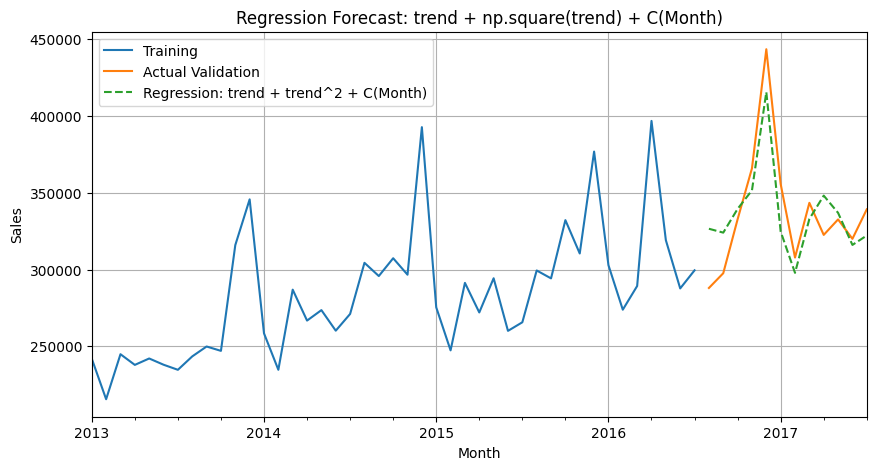

In [40]:
# Plotting for Regression: trend + trend^2 + C(Month)
plt.figure(figsize=(10,5))
train_ts.plot(label='Training')
valid_ts.plot(label='Actual Validation')
reg_pred_2.plot(label='Regression: trend + trend^2 + C(Month)', linestyle='--')
plt.title("Regression Forecast: trend + np.square(trend) + C(Month)")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

## Regression + SES on Residuals

- Trend and seasonality are first modeled using regression.
- Then Simple Exponential Smoothing is applied to the residuals to improve the forecast.

In [41]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Residuals from regression model 2
residuals_ts = reg_model_2.resid

# Apply SES on residuals
expSmooth = ExponentialSmoothing(residuals_ts, freq='MS')
expSmoothFit = expSmooth.fit(smoothing_level=0.2)

# Forecast residuals for validation period
residual_forecast = expSmoothFit.forecast(len(valid_df))

# Final forecast = regression forecast + residual forecast
reg_ses_pred = reg_pred_2 + residual_forecast


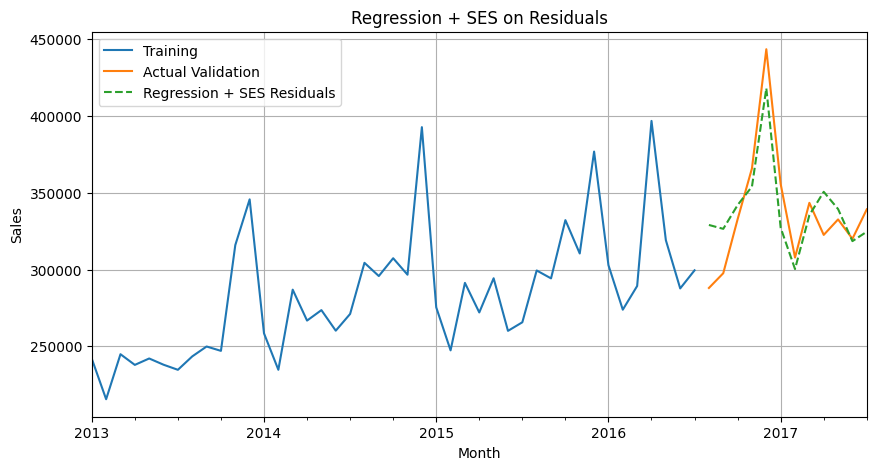

In [42]:
# Plotting the plot for Regression + SES Residuals
plt.figure(figsize=(10,5))
train_ts.plot(label='Training')
valid_ts.plot(label='Actual Validation')
reg_ses_pred.plot(label='Regression + SES Residuals', linestyle='--')
plt.title("Regression + SES on Residuals")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

## Plotting Models forecasts together

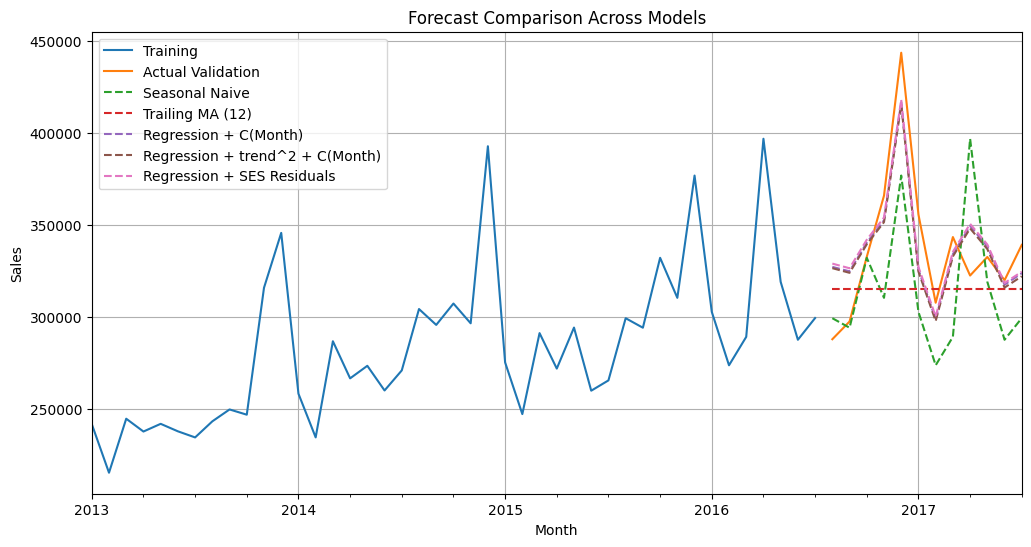

In [43]:
# Plot all model forecasts together
plt.figure(figsize=(12,6))
train_ts.plot(label='Training')
valid_ts.plot(label='Actual Validation')
seasonal_naive_pred.plot(label='Seasonal Naive', linestyle='--')
ma_trailing_pred.plot(label='Trailing MA (12)', linestyle='--')
reg_pred_1.plot(label='Regression + C(Month)', linestyle='--')
reg_pred_2.plot(label='Regression + trend^2 + C(Month)', linestyle='--')
reg_ses_pred.plot(label='Regression + SES Residuals', linestyle='--')

#Plotting the forecasting of all models combined
plt.title("Forecast Comparison Across Models")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

## Compare Forecasting Models

The models are compared using MAE, RMSE, and MAPE.
Lower values indicate better forecasting performance

In [44]:
# Seasonal Naive
mae_sn = mean_absolute_error(valid_ts, seasonal_naive_pred)
rmse_sn = np.sqrt(mean_squared_error(valid_ts, seasonal_naive_pred))
mape_sn = np.mean(np.abs((valid_ts - seasonal_naive_pred) / valid_ts)) * 100

# Trailing Moving Average
mae_ma = mean_absolute_error(valid_ts, ma_trailing_pred)
rmse_ma = np.sqrt(mean_squared_error(valid_ts, ma_trailing_pred))
mape_ma = np.mean(np.abs((valid_ts - ma_trailing_pred) / valid_ts)) * 100

# Regression: trend + C(Month)
mae_reg1 = mean_absolute_error(valid_ts, reg_pred_1)
rmse_reg1 = np.sqrt(mean_squared_error(valid_ts, reg_pred_1))
mape_reg1 = np.mean(np.abs((valid_ts - reg_pred_1) / valid_ts)) * 100

# Regression: trend + trend^2 + C(Month)
mae_reg2 = mean_absolute_error(valid_ts, reg_pred_2)
rmse_reg2 = np.sqrt(mean_squared_error(valid_ts, reg_pred_2))
mape_reg2 = np.mean(np.abs((valid_ts - reg_pred_2) / valid_ts)) * 100

# Regression + SES on residuals
mae_regses = mean_absolute_error(valid_ts, reg_ses_pred)
rmse_regses = np.sqrt(mean_squared_error(valid_ts, reg_ses_pred))
mape_regses = np.mean(np.abs((valid_ts - reg_ses_pred) / valid_ts)) * 100

# Comparison table for models comparison
results = pd.DataFrame({
    'Model': ['Seasonal Naive',
               'Trailing Moving Average',
               'Regression + C(Month)',
               'Regression + trend^2 + C(Month)',
               'Regression + SES Residuals'],
    'MAE': [mae_sn, mae_ma, mae_reg1, mae_reg2, mae_regses],
    'RMSE': [rmse_sn, rmse_ma, rmse_reg1, rmse_reg2, rmse_regses],
    'MAPE': [mape_sn, mape_ma, mape_reg1, mape_reg2, mape_regses]
})

print(results)

                             Model           MAE          RMSE       MAPE
0                   Seasonal Naive  36536.996833  43666.945008  10.504244
1          Trailing Moving Average  30951.831750  44604.310251   8.467711
2            Regression + C(Month)  17752.575409  21034.513292   5.348693
3  Regression + trend^2 + C(Month)  18035.204407  21152.007477   5.419104
4       Regression + SES Residuals  17622.692314  21169.822538   5.334801


## Combined visualization of forecasting model performance

The forecasting models are compared together using MAE, RMSE, and MAPE in  chart.

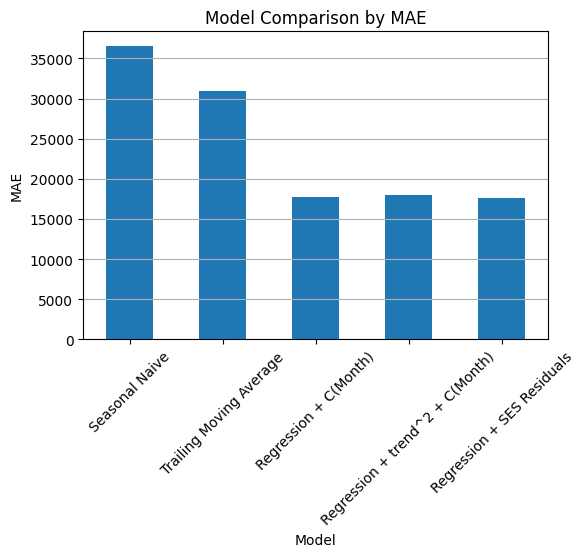

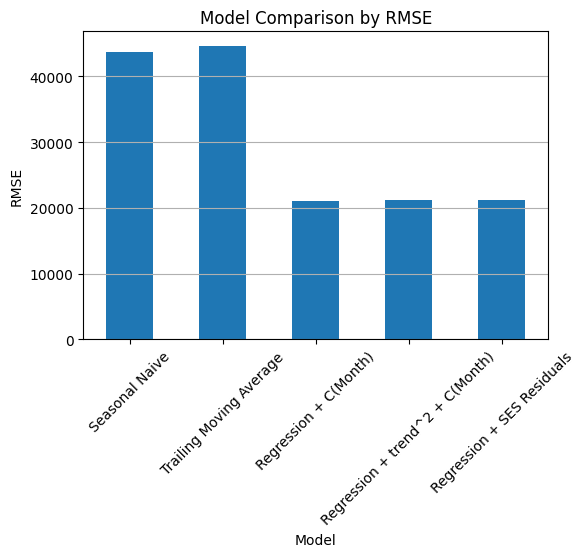

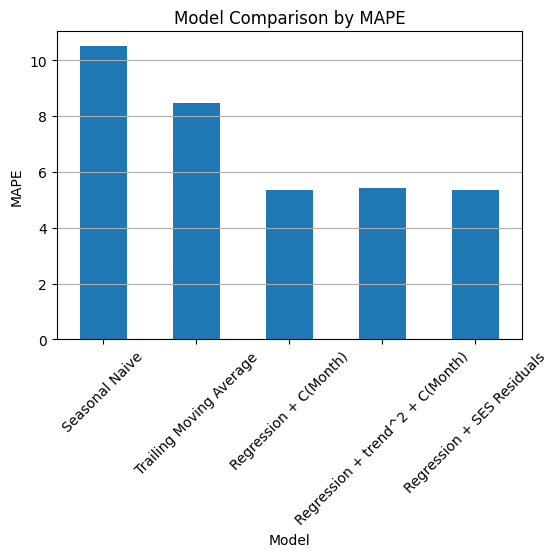

In [45]:
# Setting the model names as index
results_plot = results.set_index('Model')

# Plotting the MAE comparison plot
plt.figure(figsize=(6,4))
results_plot['MAE'].plot(kind='bar')
plt.title("Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

# Plotting the RMSE comparison plot
plt.figure(figsize=(6,4))
results_plot['RMSE'].plot(kind='bar')
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

# Plotting the MAPE comparison plot
plt.figure(figsize=(6,4))
results_plot['MAPE'].plot(kind='bar')
plt.title("Model Comparison by MAPE")
plt.xlabel("Model")
plt.ylabel("MAPE")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

In [46]:
# Find the best model for each metric
best_mae_model = results.loc[results['MAE'].idxmin(), 'Model']
best_rmse_model = results.loc[results['RMSE'].idxmin(), 'Model']
best_mape_model = results.loc[results['MAPE'].idxmin(), 'Model']

print("Best model by MAE:", best_mae_model)
print("Best model by RMSE:", best_rmse_model)
print("Best model by MAPE:", best_mape_model)

Best model by MAE: Regression + SES Residuals
Best model by RMSE: Regression + C(Month)
Best model by MAPE: Regression + SES Residuals


In [47]:
# Overall best model based on RMSE
best_model = results.loc[results['RMSE'].idxmin(), 'Model']
print("Overall best model:", best_model)

Overall best model: Regression + C(Month)


# Final Model Selection

The model comparison shows that the regression-based methods perform much better than the
Seasonal Naive and Trailing Moving Average models.

Among all models, **Regression + C(Month)** achieved the **lowest RMSE**, while
**Regression + SES Residuals** produced the lowest MAE and MAPE. However, the difference
between these two models is very small.

Since **Regression + C(Month)** provides the best RMSE and also remains simpler and easier
to interpret than the residual-smoothing model, it is selected as the final forecasting model
for monthly sales of **GROCERY I – Store 44**.

## Fit the final selected model on the full forecasting series

After comparing all models, the final selected model is **Regression + C(Month)**.
This model is now fitted on the full store-family series so it can be used to forecast
the upcoming 6 months.

In [48]:
# Fit final selected model on the full regression-ready dataframe
final_reg_model = sm.ols(formula='monthly_sales ~ trend + C(Month)', data=series_reg_df).fit()

# View model summary
print(final_reg_model.summary())

                            OLS Regression Results                            
Dep. Variable:          monthly_sales   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.813
Method:                 Least Squares   F-statistic:                     20.54
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           8.27e-14
Time:                        02:37:47   Log-Likelihood:                -615.76
No. Observations:                  55   AIC:                             1258.
Df Residuals:                      42   BIC:                             1284.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       2.398e+05   9993.262     23.

## Create the future time periods

The next 6 monthly periods are created after the last observed month.
The same lecture-based structure is used by creating:
- a future time index
- a continuing trend variable
- a Month variable for seasonality

In [49]:
# Create the next 6 monthly dates
future_index = pd.date_range(start=series_reg_df.index.max() + pd.DateOffset(months=1),
                             periods=6, freq='MS')

# Create future dataframe
future_df = pd.DataFrame(index=future_index)
future_df['trend'] = range(len(series_reg_df) + 1, len(series_reg_df) + 7)
future_df['Month'] = future_df.index.month

print(future_df)

            trend  Month
2017-08-01     56      8
2017-09-01     57      9
2017-10-01     58     10
2017-11-01     59     11
2017-12-01     60     12
2018-01-01     61      1


## Forecast the upcoming 6 months

The fitted regression model is now used to generate the forecast for the next 6 monthly periods.

In [50]:
# Forecast next 6 months
future_forecast = final_reg_model.predict(future_df)

print("6-Month Forecast:")
print(future_forecast)

6-Month Forecast:
2017-08-01    340320.382079
2017-09-01    340895.882079
2017-10-01    361364.882079
2017-11-01    378777.132079
2017-12-01    446276.391579
2018-01-01    354695.258495
Freq: MS, dtype: float64


In [51]:
# Forecast table
forecast_table = pd.DataFrame({
    'Forecast_Month': future_index,
    'Forecast_Sales': future_forecast.values
})

print(forecast_table)

  Forecast_Month  Forecast_Sales
0     2017-08-01   340320.382079
1     2017-09-01   340895.882079
2     2017-10-01   361364.882079
3     2017-11-01   378777.132079
4     2017-12-01   446276.391579
5     2018-01-01   354695.258495


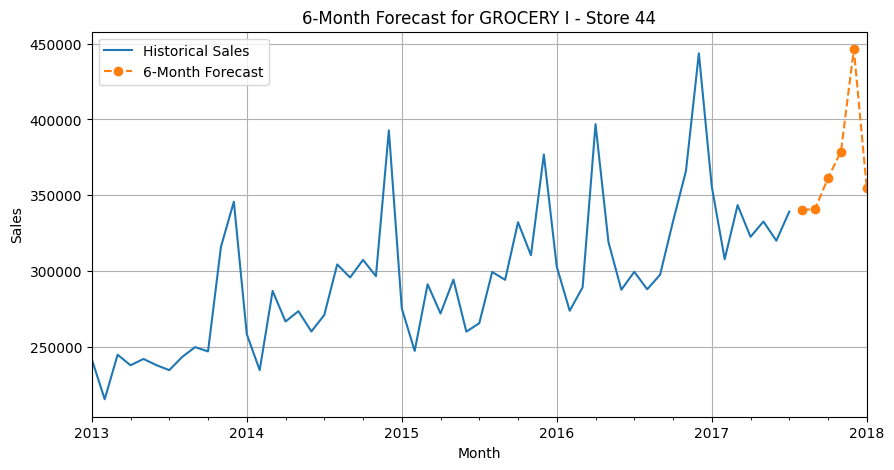

In [52]:
# Plot historical series and future forecast
plt.figure(figsize=(10,5))
series_final.plot(label='Historical Sales')
future_forecast.plot(label='6-Month Forecast', linestyle='--', marker='o')
plt.title(f"6-Month Forecast for {selected_family} - Store {selected_store}")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

### Forecast Interpretation

The chart and forecast table show the expected monthly sales for the next 6 months
for **GROCERY I – Store 44** based on the final selected regression model.

Because the model includes both trend and monthly seasonality, the forecast reflects:
- The general upward movement in sales over time
- Recurring monthly seasonal effects

These forecasted values can support future planning for inventory, replenishment, and
store-level demand decisions.

In [53]:
# Save cleaned dataset as a new Excel file
df_reset = df.reset_index()
df_reset.to_excel("clean_final_project_dataset.xlsx", index=False)

print("Excel file saved as clean_final_project_dataset.xlsx")

Excel file saved as clean_final_project_dataset.xlsx
